# Chapter 24 — The Models Were Different. Their Mistakes Weren't

**Companion to *Applied AI*.**

Three providers, three model names, three times the draws. Surely the
portfolio covers more? This notebook recomputes the frozen P1 run — 84 calls,
12 tasks, three arms — from its candidate rows, and answers the only question
variety is allowed to ask:

## Question

**How much extra coverage did model diversity actually buy?**

## What this notebook does

It **reproduces** the arm table from `p-series/p1/p1-export.json` (84
candidates, not the summary): per-arm solve sets, oracle coverage, candidate
pass rates, unique rescues in both directions, the heterogeneity premium, and
the token bill — then reads all seven failed repairs of the one unresolved
task and names the idea every model shared.

```text
coverage  ≠  model names
```

## Setup

Standard library only — plus `pandas`/`matplotlib` for the table and plot.
No network, no API key, no `codeai` import. Only bundle-relative paths are
shown; override the evidence root with `APPLIED_AI_EVIDENCE`.

In [1]:
import json
import os
from pathlib import Path

def find_evidence_dir(marker="p-series"):
    """Locate the preserved evidence. Override with APPLIED_AI_EVIDENCE."""
    env = os.environ.get("APPLIED_AI_EVIDENCE")
    if env and Path(env).expanduser().is_dir():
        return Path(env).expanduser()
    here = Path.cwd().resolve()
    for base in (here, *here.parents):
        for cand in (base / "evidence",
                     base / "experiments" / "applied-ai" / "evidence"):
            if (cand / marker).is_dir():
                return cand
    raise FileNotFoundError(
        "Preserved evidence not found. Set APPLIED_AI_EVIDENCE to the "
        "directory holding the Applied AI evidence bundles.")

EVIDENCE_DIR = find_evidence_dir()
EXPORT = EVIDENCE_DIR / "p-series" / "p1" / "p1-export.json"
print("bundle: p-series/p1/p1-export.json")
data = json.loads(EXPORT.read_text(encoding="utf-8"))
cands = data["candidates"]
calls = {c["call_id"]: c for c in data["calls"]}
print("candidates:", len(cands), "| calls:", len(calls))
print("arms: C0 = qwen x1 | C1 = qwen x3 redraws | H1 = qwen+mistral+llama")

bundle: p-series/p1/p1-export.json
candidates: 84 | calls: 84
arms: C0 = qwen x1 | C1 = qwen x3 redraws | H1 = qwen+mistral+llama


## 1. The arm table, recomputed from candidate rows

A task counts as solved for an arm if *any* of that arm's candidates passes
the hidden verifier (oracle coverage). Rescues are tasks solved by one arm
and not the other — in both directions. Nothing here is read from the
summary; every number below comes from the 84 rows:

In [2]:
from collections import defaultdict

PASS = "VERIFIER_PASS"
solved = defaultdict(set)     # arm -> solved corpus tasks
tried = defaultdict(set)      # arm -> attempted corpus tasks
passes = defaultdict(int)     # arm -> passing candidates
total = defaultdict(int)

for c in cands:
    tried[c["arm"]].add(c["corpus_task_id"])
    total[c["arm"]] += 1
    if c["outcome"] == PASS:
        solved[c["arm"]].add(c["corpus_task_id"])
        passes[c["arm"]] += 1

TASKS = sorted({c["corpus_task_id"] for c in cands})
print(f"{'task':<28}{'C0':<6}{'C1':<6}H1")
print("-" * 48)
for t in TASKS:
    print(f"{t:<28}{('X' if t in solved['C0'] else '.'):<6}"
          f"{('X' if t in solved['C1'] else '.'):<6}"
          f"{'X' if t in solved['H1'] else '.'}")

for arm in ("C0", "C1", "H1"):
    print(f"{arm}: oracle {len(solved[arm])}/{len(TASKS)}  "
          f"candidates {passes[arm]}/{total[arm]}")

rescue_h1 = solved["H1"] - solved["C1"]   # portfolio-only solves
rescue_c1 = solved["C1"] - solved["H1"]   # homogeneous-only solves
premium = len(solved["H1"]) - len(solved["C1"])
print("rescues H1-not-C1:", sorted(rescue_h1) or "none")
print("rescues C1-not-H1:", sorted(rescue_c1) or "none")
print("heterogeneity premium (H1 - C1):", float(premium))
assert solved["C0"] == solved["C1"] == solved["H1"]
assert not rescue_h1 and not rescue_c1 and premium == 0.0
assert data["report"]["heterogeneity_premium"] == 0.0
print()
print("Identical solve sets down the column. Premium 0.0, zero rescues.")

task                        C0    C1    H1
------------------------------------------------
arithmetic-boundary-clamp   X     X     X
cache-key-omission          X     X     X
dropped-condition-password  X     X     X
exception-handling-parse    X     X     X
incorrect-branching-fizzbuzzX     X     X
incorrect-default-greeting  X     X     X
inverted-comparison-adult   X     X     X
missing-validation-divide   X     X     X
off-by-one-sum              X     X     X
stale-state-average         .     .     .
wrong-identifier-mapping    X     X     X
wrong-ordering-sort         X     X     X
C0: oracle 11/12  candidates 11/12
C1: oracle 11/12  candidates 33/36
H1: oracle 11/12  candidates 33/36
rescues H1-not-C1: none
rescues C1-not-H1: none
heterogeneity premium (H1 - C1): 0.0

Identical solve sets down the column. Premium 0.0, zero rescues.


## 2. What the portfolio cost

Outcomes identical; resources not. Tokens ran 1,827 / 5,452 / 6,549 — the
portfolio at 1.20× the matched homogeneous arm, for the same verified
coverage. Money was never measured, so the supported sentence stays narrow:

C0: coverage 11/12  tokens 1827
C1: coverage 11/12  tokens 5452
H1: coverage 11/12  tokens 6549
H1 / C1 token ratio: 1.20x


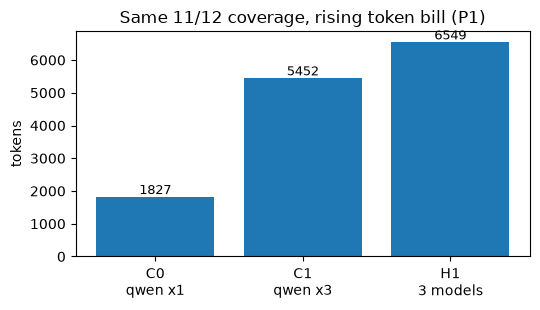

H1 spent more tokens for identical coverage. That is the whole cost sentence.


In [3]:
import matplotlib.pyplot as plt

rep = data["report"]["arms"]
toks = {a: rep[a]["tokens"] for a in ("C0", "C1", "H1")}
for a in ("C0", "C1", "H1"):
    print(f"{a}: coverage {len(solved[a])}/{len(TASKS)}  tokens {toks[a]}")
print(f"H1 / C1 token ratio: {toks['H1'] / toks['C1']:.2f}x")
assert toks == {"C0": 1827, "C1": 5452, "H1": 6549}

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.bar(["C0\nqwen x1", "C1\nqwen x3", "H1\n3 models"],
       [toks["C0"], toks["C1"], toks["H1"]])
ax.set_ylabel("tokens")
ax.set_title("Same 11/12 coverage, rising token bill (P1)")
for i, a in enumerate(("C0", "C1", "H1")):
    ax.text(i, toks[a] + 80, f"{toks[a]}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()
print("H1 spent more tokens for identical coverage. That is the whole cost sentence.")

## 3. The shared mistake

Twelve tasks, one unresolved everywhere: `stale-state-average`. On the eleven
easy tasks all 77 candidates passed — every draw, every model, every arm. On
the twelfth, all seven failed. There is no per-draw variation anywhere for a
portfolio to exploit, in either direction.

Read all seven failed repairs. Every one of them shares one idea:

In [4]:
fails = [c for c in cands if c["corpus_task_id"] == "stale-state-average"]
print("failed repairs of stale-state-average:", len(fails))
assert len(fails) == 7
for c in fails:
    first = c["diff"].splitlines()
    body = " / ".join(l for l in first if l.startswith(("+", "-")) and "+++" not in l and "---" not in l)
    print(f"  [{c['arm']:<3} {c['outcome']:<13}] {body[:100]}")

print()
print("The shared idea: keep ACCUMULATING across calls (running _n and _s),")
print("instead of computing the plain mean. Three different providers, one")
print("stale-state habit. Nominal diversity, identical mistake.")

failed repairs of stale-state-average: 7
  [C0  VERIFIER_FAIL] -        average._n = len(xs) / -        average._s = sum(xs) / +        average._n = 0 / +        a
  [C1  VERIFIER_FAIL] -        average._n = len(xs) / -        average._s = sum(xs) / +        average._n = 0 / +        a
  [C1  VERIFIER_FAIL] -        average._n = len(xs) / -        average._s = sum(xs) / +        average._n = 0 / +        a
  [C1  VERIFIER_FAIL] -        average._n = len(xs) / -        average._s = sum(xs) / +        average._n = 0 / +        a
  [H1  VERIFIER_FAIL] +    else: / +        average._n += len(xs) / +        average._s += sum(xs)
  [H1  EXECUTION_ERROR] -    if not hasattr(average, '_n'): / -        average._n = len(xs) / -        average._s = sum(xs) 
  [H1  VERIFIER_FAIL] -def average(xs): / -    if not hasattr(average, '_n'): / -        average._n = len(xs) / -        a

The shared idea: keep ACCUMULATING across calls (running _n and _s),
instead of computing the plain mean. Three differe

## Interpretation

1. **Do not infer diversity from provider names.** Three models failed the
   same task with the same idea and passed the same eleven.
2. **Premium 0.0, zero rescues, 1.20× tokens.** The portfolio bought nothing
   measurable and cost more to run.
3. **The ceiling was flat on both sides.** All 77 easy-task candidates
   passed; all 7 hard-task candidates failed. No per-draw variation means no
   portfolio — homogeneous or heterogeneous — could have helped *this* run.
4. **Scope the sentence.** Twelve tasks; a conditional-failure statistic of
   1.0 here describes one shared failure, not model errors in general. The
   chapter's title must not do that work either.

## Try it yourself

1. Recompute the table with "task solved" redefined as "majority of the
   arm's candidates pass". Does anything change? Why is oracle coverage the
   reported figure?
2. Drop `stale-state-average` from the corpus. What happens to the premium —
   and what does that say about measuring diversity on benchmarks everyone
   passes? (Chapter 25 runs this.)
3. One H1 candidate errored in execution and never reached the hidden tests
   (83 checks from 84 calls). Find it in the candidate rows: which model,
   which task?

*Evidence: `experiments/applied-ai/evidence/p-series/p1/p1-export.json`
(84 calls, 84 candidates, byte-pinned export + independent verifier). No
network, no API key, no `codeai` import.*